## 1. Import Required Libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load the GPS Trajectory Dataset


In [6]:
df = pd.read_csv("data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (2000, 15)


,Case_ID,Person_ID,Age_Group,Day,Latitude,Longitude,Timestamp,Movement_Duration_Min,Distance_km,Speed_kmh,Previous_Area,Target_Area,Hour,Weekday,Is_Weekend
0,MP-2026-001,P001,36-45,Friday,23.216252,77.431261,2026-01-02 17:38:00,19.01,6.84,21.58,Home,College,17,Friday,0
1,MP-2026-001,P001,26-35,Friday,23.205937,77.437651,2026-01-03 04:59:00,12.61,5.04,24.00,College,Mall,4,Saturday,1
2,MP-2026-001,P001,36-45,Thursday,23.212673,77.432724,2026-01-03 04:27:00,13.86,6.83,29.55,Mall,College,4,Saturday,1
3,MP-2026-001,P001,26-35,Friday,23.207000,77.437999,2026-01-02 21:38:00,28.96,6.67,13.81,College,Mall,21,Friday,0
4,MP-2026-001,P001,26-35,Thursday,23.261039,77.414497,2026-01-02 20:46:00,10.73,1.30,7.29,Mall,Home,20,Friday,0


## 3. Data Preprocessing


In [7]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.drop_duplicates()
df = df.dropna()

df = df[
    (df["Latitude"].between(-90, 90)) &
    (df["Longitude"].between(-180, 180))
]

print("Dataset after preprocessing:", df.shape)


Dataset after preprocessing: (2000, 15)


## 4. Feature Engineering


In [8]:
df["Hour"] = df["Timestamp"].dt.hour
df["Weekday_Number"] = df["Timestamp"].dt.weekday
df["Is_Weekend"] = (df["Weekday_Number"] >= 5).astype(int)

features = [
    "Hour", "Weekday_Number", "Latitude", "Longitude",
    "Speed_kmh", "Distance_km", "Movement_Duration_Min", "Is_Weekend"
]

print("Features used:")
print(features)


Features used:
['Hour', 'Weekday_Number', 'Latitude', 'Longitude', 'Speed_kmh', 'Distance_km', 'Movement_Duration_Min', 'Is_Weekend']


## 5. K-Means Movement Clustering


In [9]:
cluster_data = df[["Latitude", "Longitude"]]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Movement_Cluster"] = kmeans.fit_predict(cluster_data)

print("K-Means clustering completed.")
print(df["Movement_Cluster"].value_counts().sort_index())


K-Means clustering completed.
Movement_Cluster
0    549
1    351
2    666
3    258
4    176
Name: count, dtype: int64


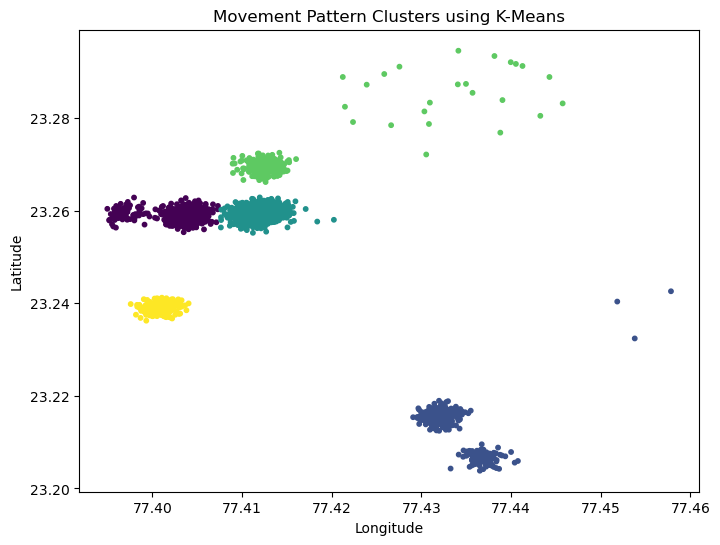

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["Longitude"], df["Latitude"],
    c=df["Movement_Cluster"], s=10
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Movement Pattern Clusters using K-Means")
plt.show()


## 6. Isolation Forest Anomaly Detection


In [11]:
anomaly_features = [
    "Latitude", "Longitude", "Speed_kmh",
    "Distance_km", "Movement_Duration_Min"
]

iso_model = IsolationForest(contamination=0.05, random_state=42)
df["Anomaly"] = iso_model.fit_predict(df[anomaly_features])
df["Is_Anomaly"] = df["Anomaly"].apply(lambda x: 1 if x == -1 else 0)

print("Anomaly detection completed.")
print("Normal records:", (df["Is_Anomaly"] == 0).sum())
print("Anomalous records:", (df["Is_Anomaly"] == 1).sum())


Anomaly detection completed.
Normal records: 1900
Anomalous records: 100


In [12]:
anomalies = df[df["Is_Anomaly"] == 1]
print("First anomalous records:")
anomalies.head(10)


First anomalous records:


,Case_ID,Person_ID,Age_Group,Day,Latitude,Longitude,Timestamp,Movement_Duration_Min,Distance_km,Speed_kmh,Previous_Area,Target_Area,Hour,Weekday,Is_Weekend,Weekday_Number,Movement_Cluster,Anomaly,Is_Anomaly
1,MP-2026-001,P001,26-35,Friday,23.205937,77.437651,2026-01-03 04:59:00,12.61,5.04,24.000000,College,Mall,4,Saturday,1,5,1,-1,1
3,MP-2026-001,P001,26-35,Friday,23.207000,77.437999,2026-01-02 21:38:00,28.96,6.67,13.810000,College,Mall,21,Friday,0,4,1,-1,1
23,MP-2026-001,P001,18-25,Thursday,23.242591,77.457829,2026-01-02 18:34:00,25.25,8.27,85.341159,Bus_Stop,College,18,Friday,0,4,1,-1,1
24,MP-2026-001,P001,36-45,Wednesday,23.289520,77.425856,2026-01-02 20:06:00,28.84,10.23,108.593488,College,Market,20,Friday,0,4,3,-1,1
30,MP-2026-001,P001,18-25,Thursday,23.259365,77.404309,2026-01-03 01:59:00,50.82,26.77,31.610000,Bus_Stop,Market,1,Saturday,1,5,0,-1,1
72,MP-2026-001,P001,26-35,Monday,23.260575,77.411167,2026-01-03 03:07:00,35.89,22.94,38.360000,Home,Bus_Stop,3,Saturday,1,5,2,-1,1
94,MP-2026-002,P002,36-45,Tuesday,23.205819,77.438355,2026-01-04 02:28:00,31.72,9.50,17.960000,College,Mall,2,Sunday,1,6,1,-1,1
113,MP-2026-002,P002,18-25,Saturday,23.258030,77.420240,2026-01-03 19:34:00,15.87,4.38,84.569825,Market,Park,19,Saturday,1,5,2,-1,1
122,MP-2026-002,P002,26-35,Wednesday,23.268754,77.411756,2026-01-04 03:24:00,34.37,22.24,38.830000,Bus_Stop,Railway,3,Sunday,1,6,3,-1,1
134,MP-2026-002,P002,26-35,Wednesday,23.206233,77.435624,2026-01-03 17:46:00,11.44,7.80,40.930000,College,Mall,17,Saturday,1,5,1,-1,1


## 7. Random Forest Location Prediction


In [13]:
label_encoder = LabelEncoder()
df["Target_Area_Encoded"] = label_encoder.fit_transform(df["Target_Area"])

X = df[features]
y = df["Target_Area_Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 1600
Testing records: 400


In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


## 8. Random Forest Model Evaluation


In [15]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Model Evaluation")
print("----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


Model Evaluation
----------------
Accuracy : 0.9575
Precision: 0.9583
Recall   : 0.9575
F1 Score : 0.9576


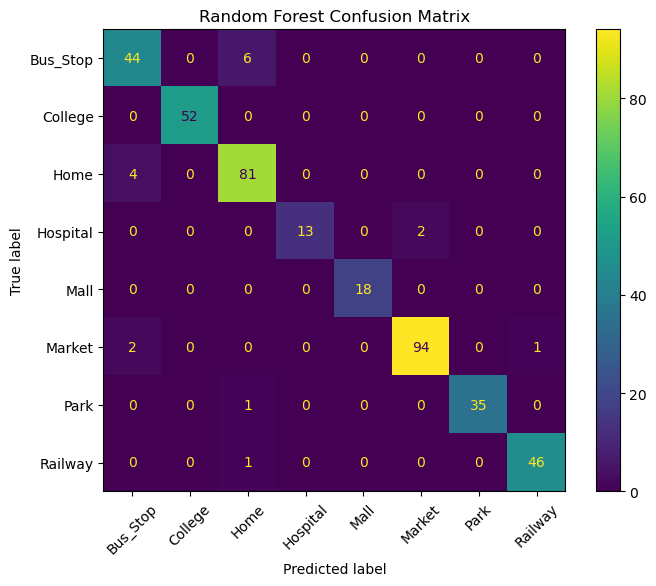

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()


## 9. Feature Importance / Explainability


In [17]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance


,Feature,Importance
3,Longitude,0.400415
2,Latitude,0.327717
4,Speed_kmh,0.137821
5,Distance_km,0.070675
6,Movement_Duration_Min,0.030759
0,Hour,0.017708
1,Weekday_Number,0.012191
7,Is_Weekend,0.002715


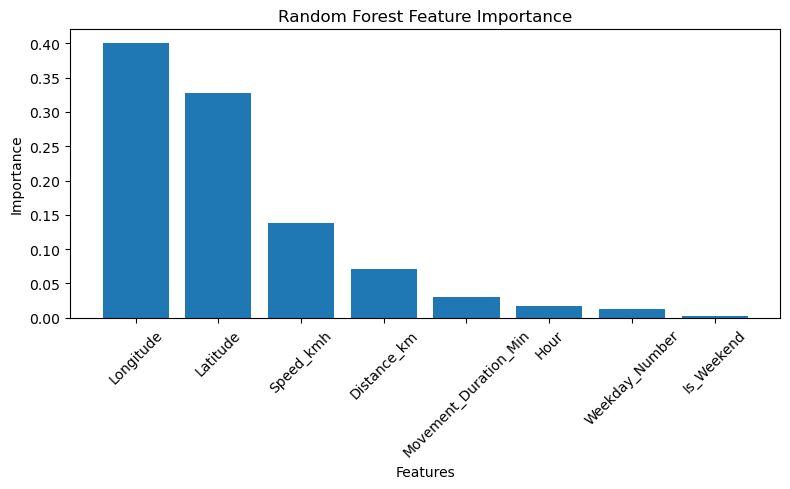

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 10. Markov Chain Route Prediction


In [19]:
transition_matrix = pd.crosstab(
    df["Previous_Area"],
    df["Target_Area"],
    normalize="index"
)

print("Markov Chain Transition Matrix:")
transition_matrix


Markov Chain Transition Matrix:


Target_Area,Bus_Stop,College,Home,Hospital,Mall,Market,Park,Railway
Previous_Area,,,,,,,,
Bus_Stop,0.012000,0.280000,0.004000,0.008000,0.008000,0.396000,0.008000,0.284000
College,0.011905,0.000000,0.341270,0.007937,0.309524,0.325397,0.000000,0.003968
Home,0.340045,0.317673,0.004474,0.008949,0.004474,0.302013,0.006711,0.015660
Hospital,0.014286,0.028571,0.314286,0.000000,0.014286,0.385714,0.242857,0.000000
Mall,0.022222,0.377778,0.366667,0.000000,0.000000,0.222222,0.011111,0.000000
Market,0.016632,0.006237,0.309771,0.008316,0.012474,0.006237,0.318087,0.322245
Park,0.011236,0.028090,0.314607,0.320225,0.011236,0.286517,0.016854,0.011236
Railway,0.344828,0.012931,0.327586,0.012931,0.004310,0.293103,0.004310,0.000000


In [20]:
def predict_route(start_area, steps=5):
    route = [start_area]
    current_area = start_area

    for _ in range(steps):
        if current_area not in transition_matrix.index:
            break

        probabilities = transition_matrix.loc[current_area]
        next_area = np.random.choice(
            probabilities.index,
            p=probabilities.values
        )

        route.append(next_area)
        current_area = next_area

    return route

start_area = df["Previous_Area"].iloc[0]
route = predict_route(start_area)

print("Starting area:", start_area)
print("Predicted probable route:")
print(" → ".join(route))


Starting area: Home
Predicted probable route:
Home → Bus_Stop → College → Mall → College → Market
